In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from IPython.display import display, Math, Latex
from scipy.fft import fft, ifft
import scipy.special as sp
import scipy.optimize 
import matplotlib.ticker as ticker
import cmath

In [2]:
Delta, w, kappa, drive, theta, phi, n_levels, step = 0, 0, 300e6*2*np.pi, 0.2, -np.pi/2, 0, 150, 30 
#no detuning w0 - wp/2, ws-wp/2, cavity decay rate, probe amplitude, drive phase, signal phase, n_levels, # of elements for drive sweep

In [ ]:
def _quadratures_from_a(a_c):
    X = (a_c + np.conj(a_c)) / np.sqrt(2)
    P = 1j * (-a_c + np.conj(a_c)) / np.sqrt(2)
    return X, P

def _gain_matrix_from_two_probes(a_out1, a_in1, a_out2, a_in2):
    Xo1, Po1 = _quadratures_from_a(a_out1)
    Xi1, Pi1 = _quadratures_from_a(a_in1)

    Xo2, Po2 = _quadratures_from_a(a_out2)
    Xi2, Pi2 = _quadratures_from_a(a_in2)

    IN  = np.array([[Xi1, Xi2],
                    [Pi1, Pi2]], dtype=complex)
    OUT = np.array([[Xo1, Xo2],
                    [Po1, Po2]], dtype=complex)

    return OUT @ np.linalg.inv(IN)

def _phase_preserving_gain_from_g(g):
    return 0.25 * np.abs(g[0,0] + g[1,1] + 1j*(g[1,0] - g[0,1]))**2

In [4]:
def _solve_two_probes_and_get_g(H0, a, kappa, drive, phi, c_ops):
    """
    Two steady-state solves:
      probe1: epsilon
      probe2: i*epsilon
    """
    def solve_for_epsilon(eps):
        a_in = 1j * eps / np.sqrt(kappa)   # bare kappa
        H_probe = eps * a.dag() + np.conj(eps) * a
        rho_ss = qt.steadystate(H0 + H_probe, c_ops)
        a_exp = qt.expect(a, rho_ss)
        a_out = np.sqrt(kappa) * a_exp + a_in  # bare kappa
        return a_out, a_in

    eps1 = drive * kappa * np.exp(-1j * phi)
    eps2 = drive * kappa * 1j * np.exp(-1j * phi)

    a_out1, a_in1 = solve_for_epsilon(eps1)
    a_out2, a_in2 = solve_for_epsilon(eps2)

    g = _gain_matrix_from_two_probes(a_out1, a_in1, a_out2, a_in2)
    G_lin = _phase_preserving_gain_from_g(g)
    return g, G_lin, eps1

In [5]:
def _vacuum_variance(op, n_levels):
    vac = qt.basis(n_levels, 0)
    exp1 = 0.5 * qt.expect(op.dag()*op + op*op.dag(), vac)
    exp2 = np.abs(qt.expect(op, vac))**2
    return exp1 - exp2

In [6]:
def jpa_params(F_JPA=np.pi/4, EC_J=85e5*2*np.pi, EJ=1900e9*2*np.pi):
    phi_zpf_JPA = (2*EC_J/EJ)**0.25
    ratio = phi_zpf_JPA**2/6
    Kerr = -EC_J * np.cos(F_JPA) / 2
    return ratio, Kerr, phi_zpf_JPA

def kfjpa_params(EC=48e5*2*np.pi, EL=1650e9*2*np.pi):
    phi_zps = (2*EC/EL)**0.25
    ratio = phi_zps**2/6
    return ratio, phi_zps

In [7]:
def parametric_metrics(
    kind,
    Delta, kappa, gamma, lam, drive, n_levels, theta, phi,
    Kerr=0.0, ratio=0.0
):
    a = qt.destroy(n_levels)

    # gamma ONLY here:
    kappa_eff = kappa + gamma
    c_ops = [np.sqrt(kappa_eff) * a]

    # Quadratic DPA Hamiltonian
    lam_phase = lam * np.exp(-1j * theta)
    H_DPA = (Delta * a.dag() * a
             + (lam_phase/2) * a.dag()*a.dag()
             + (np.conj(lam_phase)/2) * a*a)

    # Nonlinear terms
    H_nl = 0
    if kind.upper() == "DPA":
        LAM = 0.0

    elif kind.upper() == "JPA":
        LAM = -ratio * lam
        H_nl = (Kerr * a.dag()*a.dag()*a*a
                + LAM * (a.dag()*a.dag()*a.dag()*a + a.dag()*a*a*a))

    elif kind.upper() == "KFJPA":
        LAM = -ratio * lam
        H_nl = (LAM * (a.dag()*a.dag()*a.dag()*a + a.dag()*a*a*a))

    else:
        raise ValueError("kind must be one of: 'DPA', 'JPA', 'KFJPA'")

    H0 = H_DPA + H_nl

    # Gain (linear)
    g, G_lin, epsilon = _solve_two_probes_and_get_g(H0, a, kappa, drive, phi, c_ops)

    # Convenience: dB gain (DO NOT use for physics formulas)
    G_dB = 10.0 * np.log10(G_lin) if np.real(G_lin) > 0 else np.nan

    # Coefficient normalization (use linear gain)
    if kind.upper() == "DPA":
        Coeff = kappa/4 + (lam**2)/kappa
    else:
        gsw = cmath.sqrt(G_lin)
        lam_DPA = 1j * kappa * cmath.sqrt(-1 + gsw) / cmath.sqrt(-4 - 4*gsw)
        Coeff = kappa/4 + (np.abs(lam_DPA)**2)/kappa

    # ain_dag (gamma does NOT enter)
    base = ((-1j*Delta + kappa/2)*a.dag()
            - 1j*np.conj(lam_phase)*a)/np.sqrt(kappa) \
           - 1j*np.conj(epsilon)/np.sqrt(kappa)

    if kind.upper() == "DPA":
        ain_dag = base

    elif kind.upper() == "JPA":
        ain_dag = base \
            - 1j*2*Kerr*a.dag()*a.dag()*a/np.sqrt(kappa) \
            - 1j*LAM*(a.dag()*a.dag()*a.dag() + 3*a.dag()*a*a)/np.sqrt(kappa)

    elif kind.upper() == "KFJPA":
        ain_dag = base \
            + 1j*LAM*(a.dag()*a.dag()*a.dag() + 3*a.dag()*a*a)/np.sqrt(kappa)

    var_aindag = _vacuum_variance(ain_dag, n_levels)

    F = (G_lin - 1) * var_aindag / G_lin
    F_norm = F / Coeff
    eta = 1 / (1 + 2*F_norm)

    # Return BOTH gains: linear for physics, dB for plotting
    return g, G_lin, G_dB, F_norm, eta


In [8]:
def Gain_get_DPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi):
    return parametric_metrics("DPA", Delta, kappa, gamma, lam, drive, n_levels, theta, phi)

def Gain_get_JPA(Delta, kappa, gamma, lam, Kerr, drive, n_levels, theta, phi, ratio):
    return parametric_metrics("JPA", Delta, kappa, gamma, lam, drive, n_levels, theta, phi, Kerr=Kerr, ratio=ratio)

def Gain_get_KFJPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi, ratio):
    return parametric_metrics("KFJPA", Delta, kappa, gamma, lam, drive, n_levels, theta, phi, Kerr=0.0, ratio=ratio)


In [9]:
def _lam_sweep(kappa, span_factor, npts):
    return -np.linspace(0.0, span_factor, npts) * (kappa / 4.0)

def _finite_mask(*arrays):
    m = np.ones_like(arrays[0], dtype=bool)
    for a in arrays:
        m &= np.isfinite(a)
    return m

def _run_sweep_G_only(lams, fn_eval):
    """
    fn_eval(lam) -> (g, G_lin, G_dB, F_norm, eta)
    Returns: G_lin array
    """
    G = np.full(len(lams), np.nan, dtype=float)
    for i, lam in enumerate(lams):
        try:
            _, Gi, _, _, _ = fn_eval(float(lam))
            G[i] = float(np.real_if_close(Gi))
        except Exception:
            pass
    return G

def _run_sweep_G_eta(lams, fn_eval):
    """
    fn_eval(lam) -> (g, G_lin, G_dB, F_norm, eta)
    Returns: (G_lin array, eta array)
    """
    G = np.full(len(lams), np.nan, dtype=float)
    eta = np.full(len(lams), np.nan, dtype=float)
    for i, lam in enumerate(lams):
        try:
            _, Gi, _, _, etai = fn_eval(float(lam))
            G[i] = float(np.real_if_close(Gi))
            eta[i] = float(np.real_if_close(etai))
        except Exception:
            pass
    return G, eta

In [10]:
# Requires you already ran the cells defining:
#   Gain_get_DPA, Gain_get_JPA, Gain_get_KFJPA
#   jpa_params, kfjpa_params

# -----------------------------
# Sweep utilities
# -----------------------------
def _lam_sweep(kappa, span_factor, npts):
    # lam = -linspace(0, span_factor) * kappa/4  (your requested form)
    return -np.linspace(0.0, span_factor, npts) * (kappa / 4.0)

def _finite_mask(*arrays):
    m = np.ones_like(arrays[0], dtype=bool)
    for a in arrays:
        m &= np.isfinite(a)
    return m

def _run_sweep(lams, fn_eval):
    """
    fn_eval(lam) -> (g_matrix, G, F_norm, eta)
    Returns arrays G(lam), eta(lam)
    """
    G = np.full(len(lams), np.nan, dtype=float)
    eta = np.full(len(lams), np.nan, dtype=float)

    for i, lam in enumerate(lams):
        try:
            _, Gi, _, etai = fn_eval(float(lam))
            G[i] = float(np.real_if_close(Gi))
            eta[i] = float(np.real_if_close(etai))
        except Exception:
            pass

    return G, eta


# -----------------------------
# Main: separate sweeps for two plots
# -----------------------------
def plot_gain_and_efficiency_sweeps_separate(
    # common sim params
    Delta, kappa, gamma, drive, n_levels, theta, phi,

    # sweep controls
    npts_gain=30,   # for span 1.98
    npts_eta=30,   # for span 3.93

    # three JPA variants (dicts passed to jpa_params)
    jpa_param_sets=None,

    # KFJPA physical params for STS_ratio
    kfjpa_EC=48e5 * 2*np.pi,
    kfjpa_EL=1650e9 * 2*np.pi,

    figsize=(12, 5),
):
    """
    Produces:
      (1) Gain plot: x = G_DPA(lam) on lam in -[0,1.98]*kappa/4
                    y = G_design(lam) on same lam grid
      (2) Efficiency plot: x = G_design(lam) on lam in -[0,3.93]*kappa/4
                           y = eta_design(lam) on same lam grid
    for DPA, KFJPA, and 3 JPAs.
    """
    if jpa_param_sets is None:
        jpa_param_sets = [
            dict(F_JPA=np.pi/4, EC_J=85e5*2*np.pi, EJ=1900e9*2*np.pi),
            dict(F_JPA=np.pi/4, EC_J=5*85e5*2*np.pi, EJ=2000e9*2*np.pi),
            dict(F_JPA=np.pi/4, EC_J=85e4*2*np.pi, EJ=2000e9*2*np.pi),
        ]
    if len(jpa_param_sets) != 3:
        raise ValueError("jpa_param_sets must be a list of 3 dicts.")

    # ---- precompute device parameters once
    STS_ratio, _ = kfjpa_params(EC=kfjpa_EC, EL=kfjpa_EL)

    jpa_variants = []
    for i, p in enumerate(jpa_param_sets, start=1):
        ratio, Kerr, _ = jpa_params(**p)
        jpa_variants.append((f"JPA {i}", ratio, Kerr))

    # ---- lam grids
    lams_gain = _lam_sweep(kappa, span_factor=1.98, npts=npts_gain)
    lams_eta  = _lam_sweep(kappa, span_factor=3.93, npts=npts_eta)

    # =========================
    # Gain sweep (1.98)
    # =========================
    G_DPA_gain, _ = _run_sweep(
        lams_gain,
        lambda lam: Gain_get_DPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi)
    )

    gain_curves = []  # (label, G_design_gain)
    # DPA itself (optional)
    gain_curves.append(("DPA", G_DPA_gain))

    # KFJPA
    G_KF_gain, _ = _run_sweep(
        lams_gain,
        lambda lam: Gain_get_KFJPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi, STS_ratio)
    )
    gain_curves.append(("KFJPA", G_KF_gain))

    # JPAs
    for name, ratio, Kerr in jpa_variants:
        G_J_gain, _ = _run_sweep(
            lams_gain,
            lambda lam, ratio=ratio, Kerr=Kerr: Gain_get_JPA(
                Delta, kappa, gamma, lam, Kerr, drive, n_levels, theta, phi, ratio
            )
        )
        gain_curves.append((name, G_J_gain))

    # =========================
    # Eta sweep (3.93)
    # =========================
    eta_curves = []  # (label, G_design_eta, eta_design_eta)

    # DPA
    G_DPA_eta, eta_DPA_eta = _run_sweep(
        lams_eta,
        lambda lam: Gain_get_DPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi)
    )
    eta_curves.append(("DPA", G_DPA_eta, eta_DPA_eta))

    # KFJPA
    G_KF_eta, eta_KF_eta = _run_sweep(
        lams_eta,
        lambda lam: Gain_get_KFJPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi, STS_ratio)
    )
    eta_curves.append(("KFJPA", G_KF_eta, eta_KF_eta))

    # JPAs
    for name, ratio, Kerr in jpa_variants:
        G_J_eta, eta_J_eta = _run_sweep(
            lams_eta,
            lambda lam, ratio=ratio, Kerr=Kerr: Gain_get_JPA(
                Delta, kappa, gamma, lam, Kerr, drive, n_levels, theta, phi, ratio
            )
        )
        eta_curves.append((name, G_J_eta, eta_J_eta))

    # =========================
    # Plotting
    # =========================
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Plot 1: G_design vs G_DPA  (gain sweep)
    x = G_DPA_gain
    for label, y in gain_curves:
        m = _finite_mask(x, y)
        ax1.plot(x[m], y[m], lw=2, label=label)

    ax1.set_xlabel(r"DPA phase-preserving gain $G_{\mathrm{DPA}}$")
    ax1.set_ylabel(r"Design phase-preserving gain $G$")
    ax1.set_title(r"Gain comparison ($\lambda \in -[0,1.98]\cdot\kappa/4$)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Plot 2: eta vs G  (eta sweep)
    for label, Gd, etad in eta_curves:
        m = _finite_mask(Gd, etad)
        order = np.argsort(Gd[m])
        ax2.plot(Gd[m][order], etad[m][order], lw=2, label=label)

    ax2.set_xlabel(r"Phase-preserving gain $G$")
    ax2.set_ylabel(r"Quantum efficiency $\eta$")
    ax2.set_title(r"Efficiency vs gain ($\lambda \in -[0,3.93]\cdot\kappa/4$)")
    ax2.set_ylim(-0.05, 1.05)
    ax2.set_xlim(0.0, 25.0)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()

    data = {
        "lams_gain": lams_gain,
        "lams_eta": lams_eta,
        "G_DPA_gain": G_DPA_gain,
        "gain_curves": gain_curves,
        "eta_curves": eta_curves,
        "params": {
            "KFJPA": {"ratio": STS_ratio},
            "JPAs": [{"name": n, "ratio": r, "Kerr": K} for (n, r, K) in jpa_variants],
        }
    }
    return fig, (ax1, ax2), data


In [11]:
def plot_gain_and_efficiency_sweeps_separate(
    Delta, kappa, gamma, drive, n_levels, theta, phi,
    npts_gain=30,
    npts_eta=30,
    jpa_param_sets=None,
    kfjpa_EC=48e5 * 2*np.pi,
    kfjpa_EL=1650e9 * 2*np.pi,
    plot_in_dB=False,   # if True, axes use dB; internally still linear
    figsize=(12, 5),
):
    if jpa_param_sets is None:
        jpa_param_sets = [
            dict(F_JPA=np.pi/4, EC_J=85e5*2*np.pi, EJ=1900e9*2*np.pi),
            dict(F_JPA=np.pi/4, EC_J=5*85e5*2*np.pi, EJ=2000e9*2*np.pi),
            dict(F_JPA=np.pi/4, EC_J=85e4*2*np.pi, EJ=2000e9*2*np.pi),
        ]
    if len(jpa_param_sets) != 3:
        raise ValueError("jpa_param_sets must be a list of 3 dicts.")

    # Precompute device parameters once
    STS_ratio, _ = kfjpa_params(EC=kfjpa_EC, EL=kfjpa_EL)
    jpa_variants = []
    for i, p in enumerate(jpa_param_sets, start=1):
        ratio, Kerr, _ = jpa_params(**p)
        jpa_variants.append((f"JPA {i}", ratio, Kerr))

    # Lam grids (separate sweeps)
    lams_gain = _lam_sweep(kappa, 1.98, npts_gain)
    lams_eta  = _lam_sweep(kappa, 3.93, npts_eta)

    # -------------------------
    # Gain sweep: compute G only (faster)
    # -------------------------
    G_DPA_gain = _run_sweep_G_only(
        lams_gain,
        lambda lam: Gain_get_DPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi)
    )

    gain_curves = [("DPA", G_DPA_gain)]

    G_KF_gain = _run_sweep_G_only(
        lams_gain,
        lambda lam: Gain_get_KFJPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi, STS_ratio)
    )
    gain_curves.append(("KFJPA", G_KF_gain))

    for name, ratio, Kerr in jpa_variants:
        G_J_gain = _run_sweep_G_only(
            lams_gain,
            lambda lam, ratio=ratio, Kerr=Kerr: Gain_get_JPA(
                Delta, kappa, gamma, lam, Kerr, drive, n_levels, theta, phi, ratio
            )
        )
        gain_curves.append((name, G_J_gain))

    # -------------------------
    # Eta sweep: compute (G, eta)
    # -------------------------
    eta_curves = []

    G_DPA_eta, eta_DPA_eta = _run_sweep_G_eta(
        lams_eta,
        lambda lam: Gain_get_DPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi)
    )
    eta_curves.append(("DPA", G_DPA_eta, eta_DPA_eta))

    G_KF_eta, eta_KF_eta = _run_sweep_G_eta(
        lams_eta,
        lambda lam: Gain_get_KFJPA(Delta, kappa, gamma, lam, drive, n_levels, theta, phi, STS_ratio)
    )
    eta_curves.append(("KFJPA", G_KF_eta, eta_KF_eta))

    for name, ratio, Kerr in jpa_variants:
        G_J_eta, eta_J_eta = _run_sweep_G_eta(
            lams_eta,
            lambda lam, ratio=ratio, Kerr=Kerr: Gain_get_JPA(
                Delta, kappa, gamma, lam, Kerr, drive, n_levels, theta, phi, ratio
            )
        )
        eta_curves.append((name, G_J_eta, eta_J_eta))

    # -------------------------
    # Plotting (convert to dB here if requested)
    # -------------------------
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Plot 1: y = design gain vs x = DPA gain
    x = G_DPA_gain.copy()
    if plot_in_dB:
        x = 10*np.log10(x)

    for label, y in gain_curves:
        yy = y.copy()
        if plot_in_dB:
            yy = 10*np.log10(yy)
        m = _finite_mask(x, yy)
        ax1.plot(x[m], yy[m], lw=2, label=label)

    ax1.set_xlabel(r"$G_{\mathrm{DPA}}$ (dB)" if plot_in_dB else r"$G_{\mathrm{DPA}}$")
    ax1.set_ylabel(r"$G$ (dB)" if plot_in_dB else r"$G$")
    ax1.set_title(r"Gain comparison ($\lambda \in -[0,1.98]\cdot\kappa/4$)")
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # Plot 2: eta vs gain
    for label, G_lin, eta in eta_curves:
        xx = G_lin.copy()
        if plot_in_dB:
            xx = 10*np.log10(xx)
        m = _finite_mask(xx, eta)
        order = np.argsort(xx[m])
        ax2.plot(xx[m][order], eta[m][order], lw=2, label=label)

    ax2.set_xlabel(r"$G$ (dB)" if plot_in_dB else r"$G$")
    ax2.set_ylabel(r"$\eta$")
    ax2.set_title(r"Efficiency vs gain ($\lambda \in -[0,3.93]\cdot\kappa/4$)")
    ax2.set_xlim(0.0, 25.0)
    ax2.set_ylim(-0.05, 1.05)
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()

    data = {
        "lams_gain": lams_gain,
        "lams_eta": lams_eta,
        "G_DPA_gain": G_DPA_gain,
        "gain_curves": gain_curves,
        "eta_curves": eta_curves,
    }
    return fig, (ax1, ax2), data


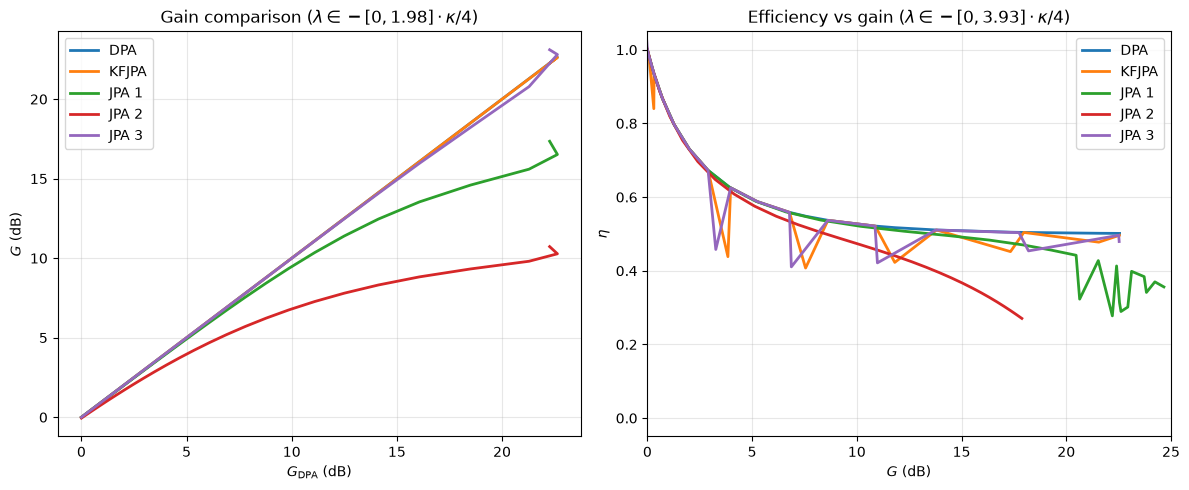

In [12]:
fig, axes, data = plot_gain_and_efficiency_sweeps_separate(
    Delta,
    kappa,
    0.0,
    drive,
    80,
    theta,
    phi,
    plot_in_dB=True,  # <- optional
    jpa_param_sets=[
        dict(F_JPA=np.pi/4, EC_J=85e5*2*np.pi, EJ=1900e9*2*np.pi),
        dict(F_JPA=np.pi/4, EC_J=5*85e5*2*np.pi, EJ=2000e9*2*np.pi),
        dict(F_JPA=np.pi/4, EC_J=85e4*2*np.pi, EJ=2000e9*2*np.pi),
    ],
)
plt.show()

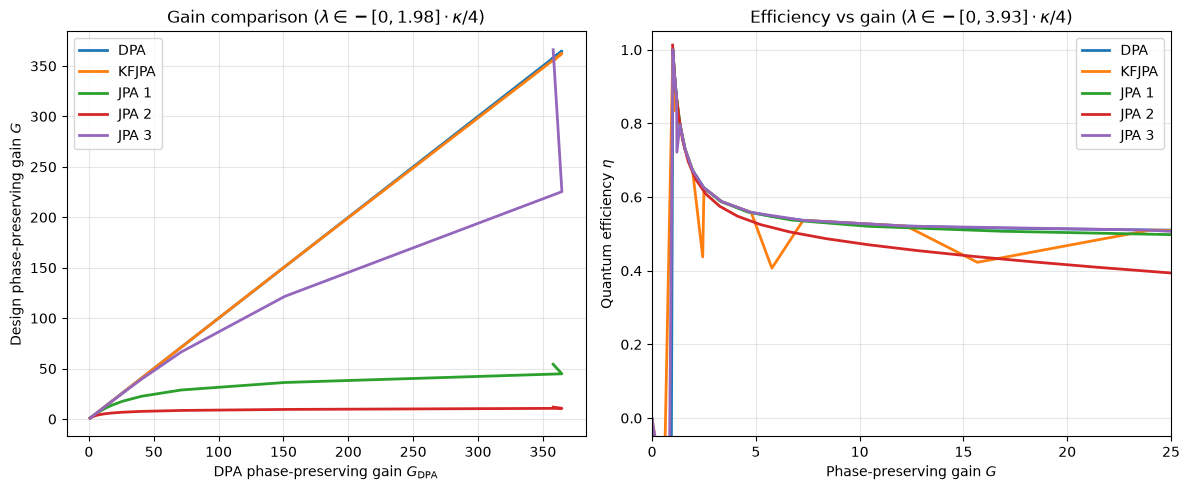

In [15]:
fig, axes, data = plot_gain_and_efficiency_sweeps_separate(
    Delta,
    kappa,
    0.0,
    drive,
    150,
    theta,
    phi,
    jpa_param_sets=[
        dict(F_JPA=np.pi/4, EC_J=85e5*2*np.pi, EJ=1900e9*2*np.pi),
        dict(F_JPA=np.pi/4, EC_J=5*85e5*2*np.pi, EJ=2000e9*2*np.pi),
        dict(F_JPA=np.pi/4, EC_J=85e4*2*np.pi, EJ=2000e9*2*np.pi),
    ],
)
plt.show()